# Heart Disease Prediction using XGBoost

This notebook covers:
1. Loading and exploring the heart disease data
2. Data preprocessing and scaling
3. Training an XGBoost Classifier
4. Evaluating model performance
5. Saving the model and scaler for deployment

In [21]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load the Dataset

In [22]:
# Load dataset
try:
    df = pd.read_csv('../data/heart_disease.csv')
except FileNotFoundError:
    # Try relative path from project root if running there
    df = pd.read_csv('data/heart_disease.csv')

# Display basic info
print(f"Total samples: {len(df)}")
print(f"Features: {df.shape[1] - 1}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())

df.head()

Total samples: 20000
Features: 13

Target distribution:
target
1    10000
0    10000
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,0,1,145,244,0,2,139,0,3.4,0,2,2,1
1,37,1,1,122,217,0,1,174,0,1.1,1,0,2,0
2,44,1,2,107,257,0,2,148,0,1.0,2,0,0,0
3,64,0,3,119,215,0,2,166,0,0.0,2,0,0,0
4,54,1,0,139,275,0,0,112,1,3.4,0,1,2,1


## 2. Data Preprocessing

In [23]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [24]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 16000 samples
Test set: 4000 samples


In [25]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed using StandardScaler.")

Feature scaling completed using StandardScaler.


## 3. Train XGBoost Model

In [26]:
# Initialize XGBoost Classifier
model = xgb.XGBClassifier(
    max_depth=5,
    learning_rate=0.1,
    n_estimators=200,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    random_state=42,
    eval_metric='error',
    n_jobs=-1
)

# Train the model
print("Training model...")
model.fit(
    X_train_scaled,
    y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=False
)
print("Model training completed!")

Training model...


Model training completed!


## 4. Evaluate Performance

In [27]:
# XGBoost predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Accuracy summary
train_accuracy_score = accuracy_score(y_train, y_train_pred)
val_accuracy_score = accuracy_score(y_test, y_test_pred)

print("=" * 38)
print("XGBOOST PERFORMANCE SUMMARY")
print("=" * 38)
print(f"Training Accuracy:   {train_accuracy_score:.4f}")
print(f"Validation Accuracy: {val_accuracy_score:.4f}")

XGBOOST PERFORMANCE SUMMARY
Training Accuracy:   0.9868
Validation Accuracy: 0.9710


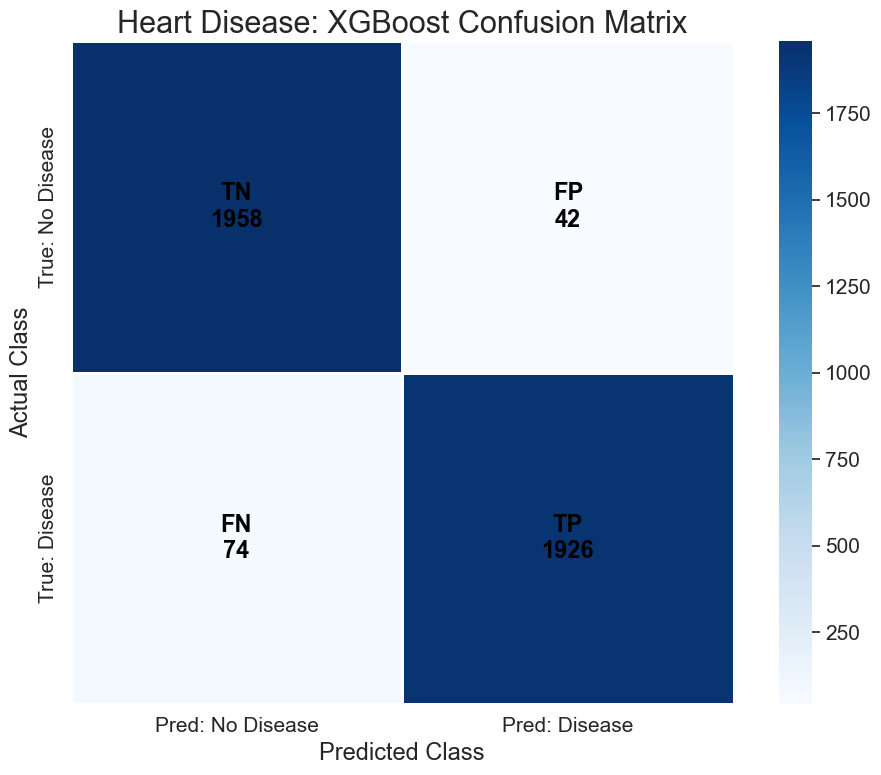

In [28]:
# Confusion Matrix (XGBoost) with explicit TN/FP/FN/TP labels
os.makedirs('../models/plots', exist_ok=True)
cm = confusion_matrix(y_test, y_test_pred)

sns.set_theme(style='white')
plt.rcParams.update({
    'font.size': 15,
    'axes.titlesize': 22,
    'axes.labelsize': 17,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15
})

if cm.shape == (2, 2):
    cm_annot = np.array([
        [f"TN\n{cm[0, 0]}", f"FP\n{cm[0, 1]}"],
        [f"FN\n{cm[1, 0]}", f"TP\n{cm[1, 1]}"]
    ])
else:
    cm_annot = cm.astype(str)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=cm_annot,
    fmt='',
    cmap='Blues',
    cbar=True,
    linewidths=0.8,
    linecolor='white',
    square=True,
    annot_kws={'size': 17, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Pred: No Disease', 'Pred: Disease'],
    yticklabels=['True: No Disease', 'True: Disease']
)
plt.title('Heart Disease: XGBoost Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.savefig('../models/plots/heart_disease_xgb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

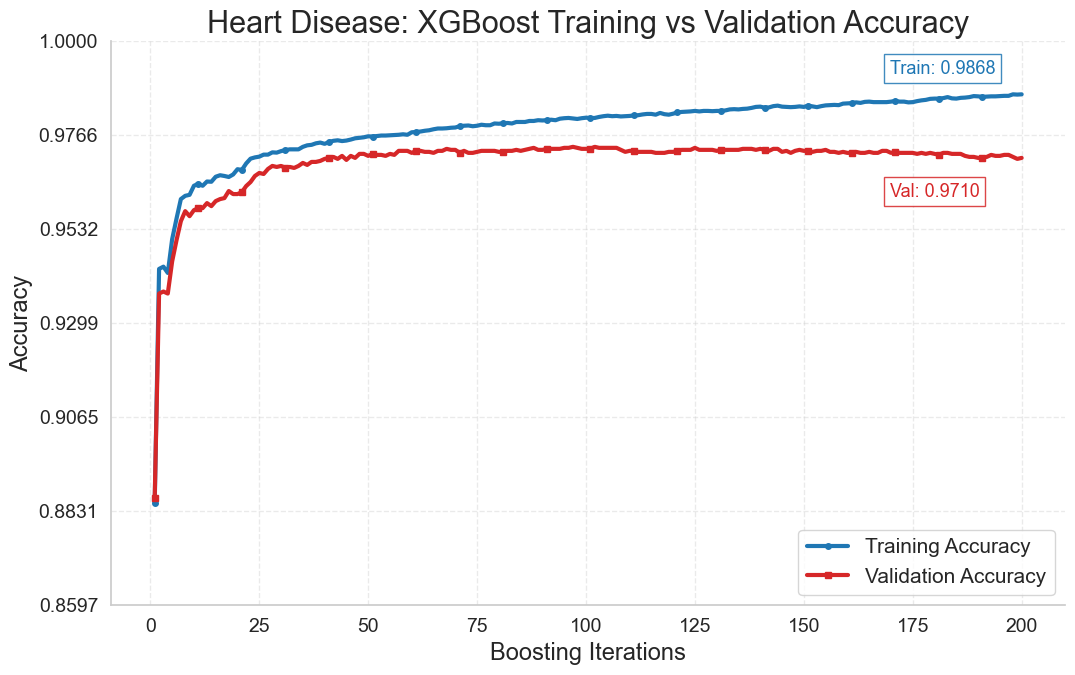

In [29]:
# Training vs Validation Accuracy Curve (XGBoost) with improved readability
os.makedirs('../models/plots', exist_ok=True)

evals = model.evals_result()
train_accuracy_curve = 1 - np.asarray(evals['validation_0']['error'])
val_accuracy_curve = 1 - np.asarray(evals['validation_1']['error'])
iterations = np.arange(1, len(train_accuracy_curve) + 1)

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'font.size': 15,
    'axes.titlesize': 22,
    'axes.labelsize': 17,
    'legend.fontsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})

y_min = float(min(train_accuracy_curve.min(), val_accuracy_curve.min()))
y_max = float(max(train_accuracy_curve.max(), val_accuracy_curve.max()))
pad = max(0.004, (y_max - y_min) * 0.25)
lower = max(0.0, y_min - pad)
upper = min(1.0, y_max + pad)
mark_every = max(1, len(iterations) // 20)

plt.figure(figsize=(11, 7))
plt.plot(
    iterations,
    train_accuracy_curve,
    label='Training Accuracy',
    color='#1f77b4',
    linewidth=3.0,
    marker='o',
    markersize=4,
    markevery=mark_every
)
plt.plot(
    iterations,
    val_accuracy_curve,
    label='Validation Accuracy',
    color='#d62728',
    linewidth=3.0,
    marker='s',
    markersize=4,
    markevery=mark_every
)

plt.title('Heart Disease: XGBoost Training vs Validation Accuracy')
plt.xlabel('Boosting Iterations')
plt.ylabel('Accuracy')
plt.ylim(lower, upper)
plt.yticks(np.round(np.linspace(lower, upper, 7), 4))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='lower right', frameon=True)

plt.annotate(
    f"Train: {train_accuracy_curve[-1]:.4f}",
    xy=(iterations[-1], train_accuracy_curve[-1]),
    xytext=(-95, 15),
    textcoords='offset points',
    fontsize=13,
    color='#1f77b4',
    bbox=dict(facecolor='white', edgecolor='#1f77b4', alpha=0.85)
)
plt.annotate(
    f"Val: {val_accuracy_curve[-1]:.4f}",
    xy=(iterations[-1], val_accuracy_curve[-1]),
    xytext=(-95, -28),
    textcoords='offset points',
    fontsize=13,
    color='#d62728',
    bbox=dict(facecolor='white', edgecolor='#d62728', alpha=0.85)
)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../models/plots/heart_disease_xgb_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Save Model and Scaler

In [30]:
# Create models directory (relative to notebook location)
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save the Scaler
scaler_path = os.path.join(models_dir, 'heart_scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to: {scaler_path}")

# Save the XGBoost model
model_path = os.path.join(models_dir, 'heart_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
print(f"Model saved to: {model_path}")

Scaler saved to: ../models\heart_scaler.pkl
Model saved to: ../models\heart_model.pkl
